In [2]:
from utilities import DataSimulator, prepare_data,plot_learning_curve, analyze_error_distribution, ks_test_gan_cdf,plot_bin_dist 
from my_cGAN import MyCGAN
import pandas as pd
import numpy as np


# DATA MANAGEMENT

In [5]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 3        # Number of time steps
J = 2        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.get_paths()
sim.get_pdf(n_steps_ahead=10, n_bins=3)
sim.save_binary_file('data/inputs/demo')
print(sim.paths)
print(sim.pdf)

Are all probability rows identical? True
file stored in data/inputs/demo.bin
[[ 0.77395605  0.77946721  0.76059986  0.75817074]
 [ 0.43887844 -0.20028035  0.1364279   0.41590248]]
[[0.09117955 0.81757756 0.09117955]
 [0.09117955 0.81757756 0.09117955]]


In [6]:
file_paths, file_pdf = sim.load_binary_file('data/inputs/demo.bin')

processed binary file


In [7]:
print(file_paths)
print(file_pdf)

[[ 0.77395605  0.77946721  0.76059986  0.75817074]
 [ 0.43887844 -0.20028035  0.1364279   0.41590248]]
[[0.09117955 0.81757756 0.09117955]
 [0.09117955 0.81757756 0.09117955]]


# MEAN AND VARIANCE

In [2]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10)

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='standardization')


conditional_gan = MyCGAN(max_epoch= 100, name = 'CGAN_mean_std')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'mean_std_error_dist.csv')


Epoch: 0/100, Step: 0, D Loss: 1.4059211015701294, G Loss: 0.7193750739097595
Epoch: 0/100, Step: 500, D Loss: 1.3669769763946533, G Loss: 0.6678935885429382
Epoch: 0/100, Step: 1000, D Loss: 1.3883306980133057, G Loss: 0.6988725066184998
Epoch: 0/100, Step: 1500, D Loss: 1.391775131225586, G Loss: 0.6957070827484131


c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\my_cGAN.py:427: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  D_loss_list.append(round(float(D_loss), 4))


Epoch: 0/100, Step: 2000, D Loss: 1.3888027667999268, G Loss: 0.7002123594284058
Epoch: 0/100, Step: 2500, D Loss: 1.3779631853103638, G Loss: 0.7002137303352356
Epoch: 0/100, Step: 3000, D Loss: 1.3795013427734375, G Loss: 0.6887571811676025
Epoch: 1/100, Step: 3500, D Loss: 1.3750343322753906, G Loss: 0.7187780141830444
Epoch: 1/100, Step: 4000, D Loss: 1.3772921562194824, G Loss: 0.7514622807502747
Epoch: 1/100, Step: 4500, D Loss: 1.383636713027954, G Loss: 0.6858837008476257
Epoch: 1/100, Step: 5000, D Loss: 1.3833900690078735, G Loss: 0.714773416519165
Epoch: 1/100, Step: 5500, D Loss: 1.3675181865692139, G Loss: 0.7177178263664246
Epoch: 1/100, Step: 6000, D Loss: 1.3695335388183594, G Loss: 0.7729098796844482
Epoch: 2/100, Step: 6500, D Loss: 1.3087921142578125, G Loss: 0.9587804675102234
Epoch: 2/100, Step: 7000, D Loss: 1.1416065692901611, G Loss: 1.072570562362671
Epoch: 2/100, Step: 7500, D Loss: 1.0106561183929443, G Loss: 1.8137062788009644
Epoch: 2/100, Step: 8000, D Los

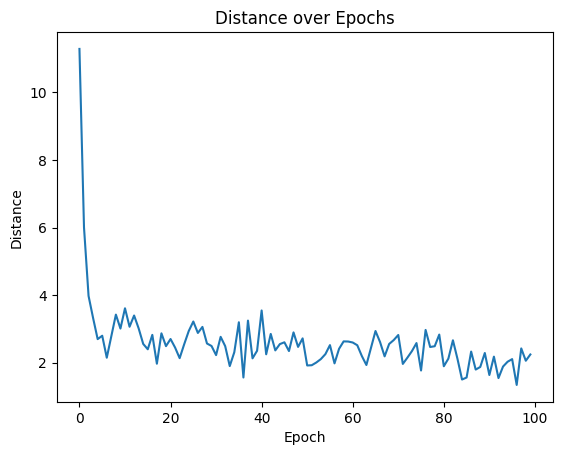

In [4]:
plot_learning_curve('generated_vs_true.csv')

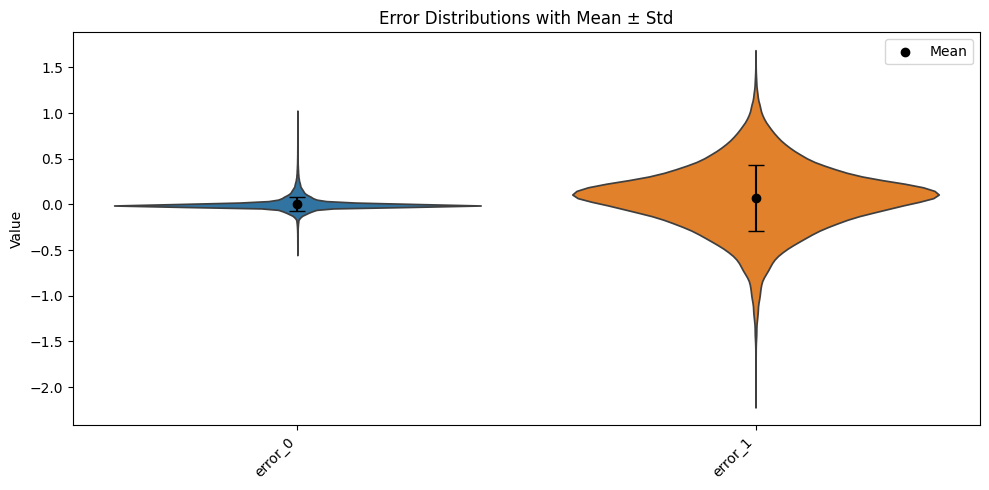

error_0    0.005486
error_1    0.075123
dtype: float64 
 error_0    0.074646
error_1    0.360826
dtype: float64 
              mean       std    median      skew   kurtosis  is_zero_test
error_0  0.005486  0.074646 -0.008105  2.326250  14.010289         False
error_1  0.075123  0.360826  0.089637 -0.247794   1.304691         False


In [2]:
means, std, summary = analyze_error_distribution('./data/results/mean_std_error_dist.csv')
print(means,'\n', std, '\n', summary)

# BINS DISTRIBUTION PROBABILITIES 1


In [8]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100, verbose=True)
pdfs

Mean values - unique: (100,), min: -2.0448548406664235, max: 2.0784605024823306
Std values - unique: (100,), min: 0.0029726035560525615, max: 0.19513922000154846
First 5 means: [ 0.58455083 -1.18721202  0.57648137  0.69446668  0.08626536]
First 5 stds: [0.15490709 0.19359807 0.09984949 0.02883561 0.0029726 ]
First 3 samples' first 5 bin edges:
[[-0.03507754 -0.02268497 -0.0102924   0.00210016  0.01449273]
 [-1.9616043  -1.94611645 -1.93062861 -1.91514076 -1.89965292]
 [ 0.17708342  0.18507138  0.19305934  0.2010473   0.20903526]]
Are all rows identical? False
First 3 samples' first 5 bin edges standardized:
[[-4.   -3.92 -3.84 -3.76 -3.68]
 [-4.   -3.92 -3.84 -3.76 -3.68]
 [-4.   -3.92 -3.84 -3.76 -3.68]]
Are all rows identical standardized? True
Are all probability rows identical? True


array([[1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       ...,
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05]], shape=(100, 100))

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
pdfs

Are all probability rows identical? True


array([[1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       ...,
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05],
       [1.26032425e-05, 1.72426709e-05, 2.34395233e-05, ...,
        2.34395233e-05, 1.72426709e-05, 1.26032425e-05]],
      shape=(1000, 100))

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_p_error_dist.csv')


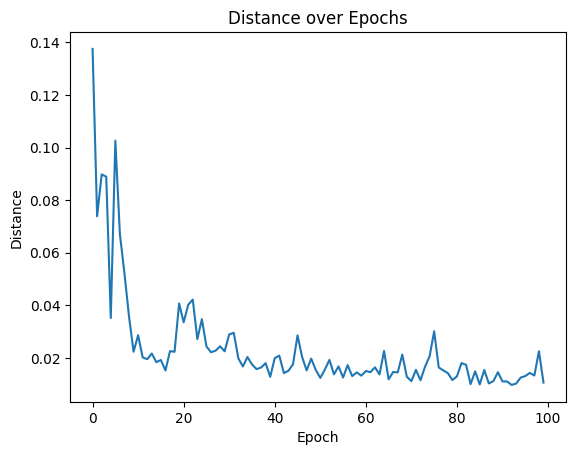

In [11]:
plot_learning_curve('generated_vs_true.csv')

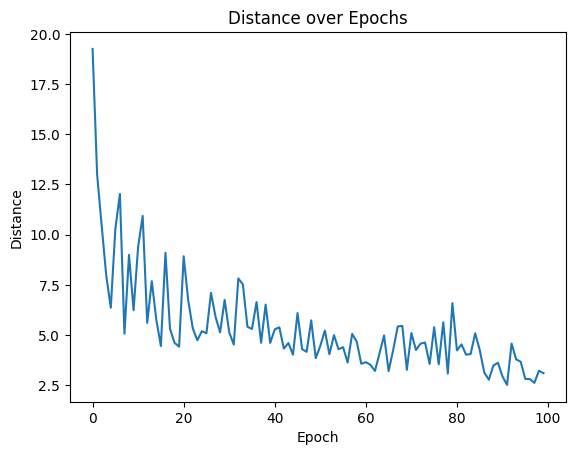

In [4]:
plot_learning_curve('generated_vs_true.csv')

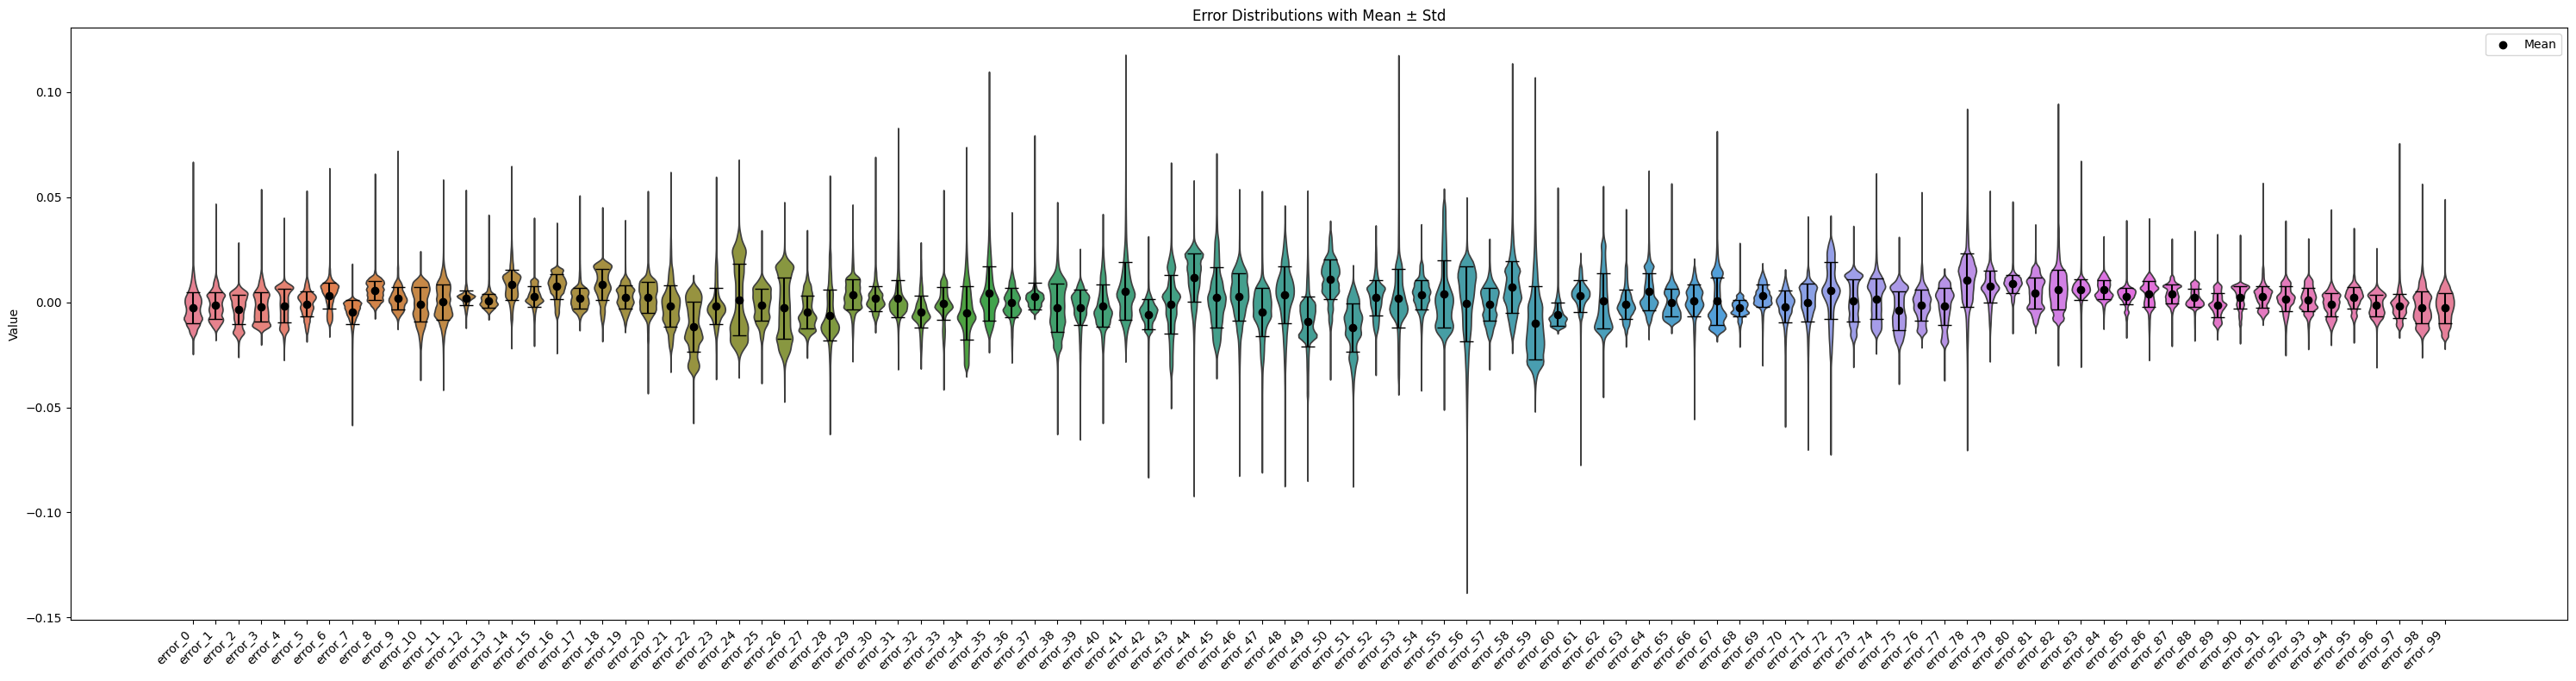

error_0    -0.002629
error_1    -0.001518
error_2    -0.003471
error_3    -0.002169
error_4    -0.001636
              ...   
error_95    0.002152
error_96   -0.001471
error_97   -0.001816
error_98   -0.002500
error_99   -0.002640
Length: 100, dtype: float64 
 error_0     0.007401
error_1     0.006244
error_2     0.007125
error_3     0.006982
error_4     0.007943
              ...   
error_95    0.005025
error_96    0.005132
error_97    0.005814
error_98    0.007606
error_99    0.007172
Length: 100, dtype: float64 
               mean       std    median      skew  kurtosis  is_zero_test
error_0  -0.002629  0.007401 -0.002944  0.372987  0.066468         False
error_1  -0.001518  0.006244 -0.001509  0.096317 -0.757230         False
error_2  -0.003471  0.007125 -0.002174 -0.385574 -0.997832         False
error_3  -0.002169  0.006982 -0.002577  0.266079 -0.721484         False
error_4  -0.001636  0.007943 -0.000736 -0.294469 -1.031563         False
...            ...       ...       ...  

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/bins_p_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
summary

## ks test 

In [10]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=1

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = val.get_paths()
pdfs= val.get_pdf(n_steps_ahead=10, n_bins=100)

Are all probability rows identical? True


In [ ]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.load_models()

CGAN config loaded from ./models\CGAN_bins_config.json
Generator loaded from ./models\CGAN_bins_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [128, 256, 128], 'use_batch_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0, 'is_prob': True}
Discriminator loaded from ./models\CGAN_bins_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [256, 128], 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}


In [18]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)


In [19]:
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df

,p_values
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
95,1.0
96,1.0
97,1.0
98,1.0


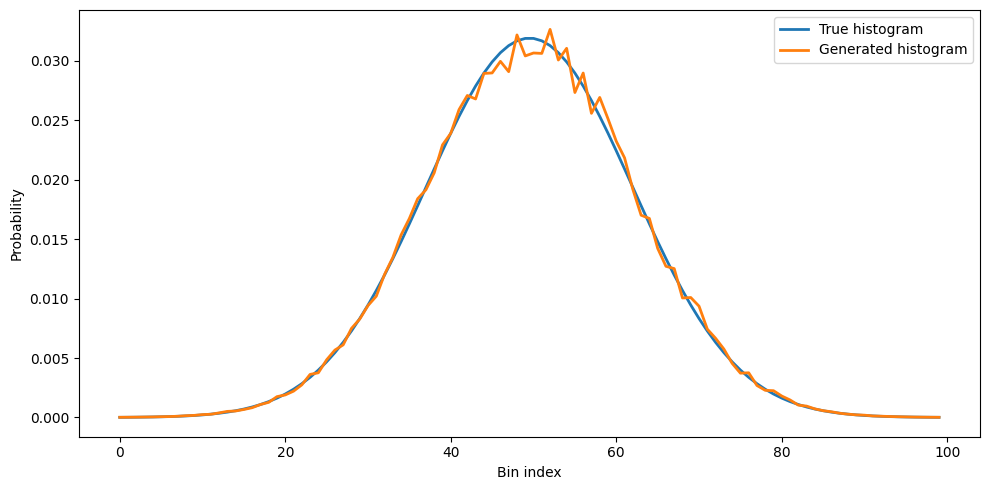

In [20]:
generated_sample = generated[-1]
true_sample = pdfs[-1]

plot_bin_dist(true_sample, generated_sample)



# BINS DISTRIBUTION PROBABILITIES 2


In [3]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100, use_global=True)
pdfs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100000, 100))

In [4]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=200, name='CGAN_bins_pglobal')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_pglobal_error_dist.csv')


Epoch: 0/200, Step: 0, D Loss: 2.3187482357025146, G Loss: 0.5071411728858948
Epoch: 0/200, Step: 500, D Loss: 0.8856682777404785, G Loss: 1.2358224391937256
Epoch: 0/200, Step: 1000, D Loss: 1.1374125480651855, G Loss: 0.8211135864257812
Epoch: 0/200, Step: 1500, D Loss: 1.1558146476745605, G Loss: 1.038629412651062


c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\my_cGAN.py:422: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  D_loss_list.append(round(float(D_loss), 4))


Epoch: 0/200, Step: 2000, D Loss: 1.1717641353607178, G Loss: 0.9664551615715027
Epoch: 0/200, Step: 2500, D Loss: 1.264012098312378, G Loss: 0.9918119311332703
Epoch: 0/200, Step: 3000, D Loss: 1.2698516845703125, G Loss: 1.179648756980896
Epoch: 1/200, Step: 3500, D Loss: 1.1742433309555054, G Loss: 0.6415660977363586
Epoch: 1/200, Step: 4000, D Loss: 1.191477656364441, G Loss: 0.7334251403808594
Epoch: 1/200, Step: 4500, D Loss: 1.3715769052505493, G Loss: 0.9089160561561584
Epoch: 1/200, Step: 5000, D Loss: 1.183833122253418, G Loss: 1.1854864358901978
Epoch: 1/200, Step: 5500, D Loss: 1.2837547063827515, G Loss: 1.401737928390503
Epoch: 1/200, Step: 6000, D Loss: 1.2193892002105713, G Loss: 0.8467955589294434
Epoch: 2/200, Step: 6500, D Loss: 1.2520815134048462, G Loss: 0.9535320997238159
Epoch: 2/200, Step: 7000, D Loss: 1.2882353067398071, G Loss: 0.6490325927734375
Epoch: 2/200, Step: 7500, D Loss: 1.10076105594635, G Loss: 1.1400368213653564
Epoch: 2/200, Step: 8000, D Loss: 1

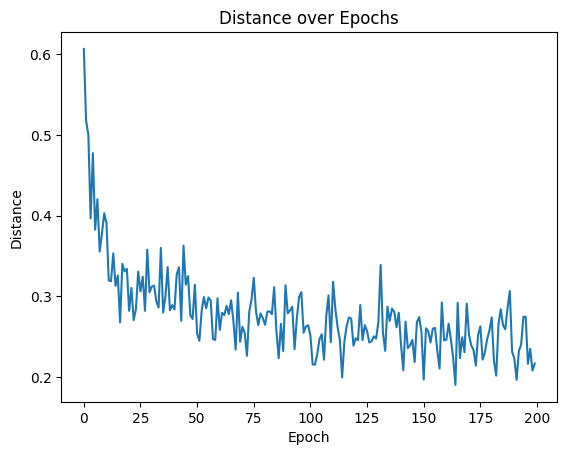

In [5]:
plot_learning_curve('generated_vs_true.csv')

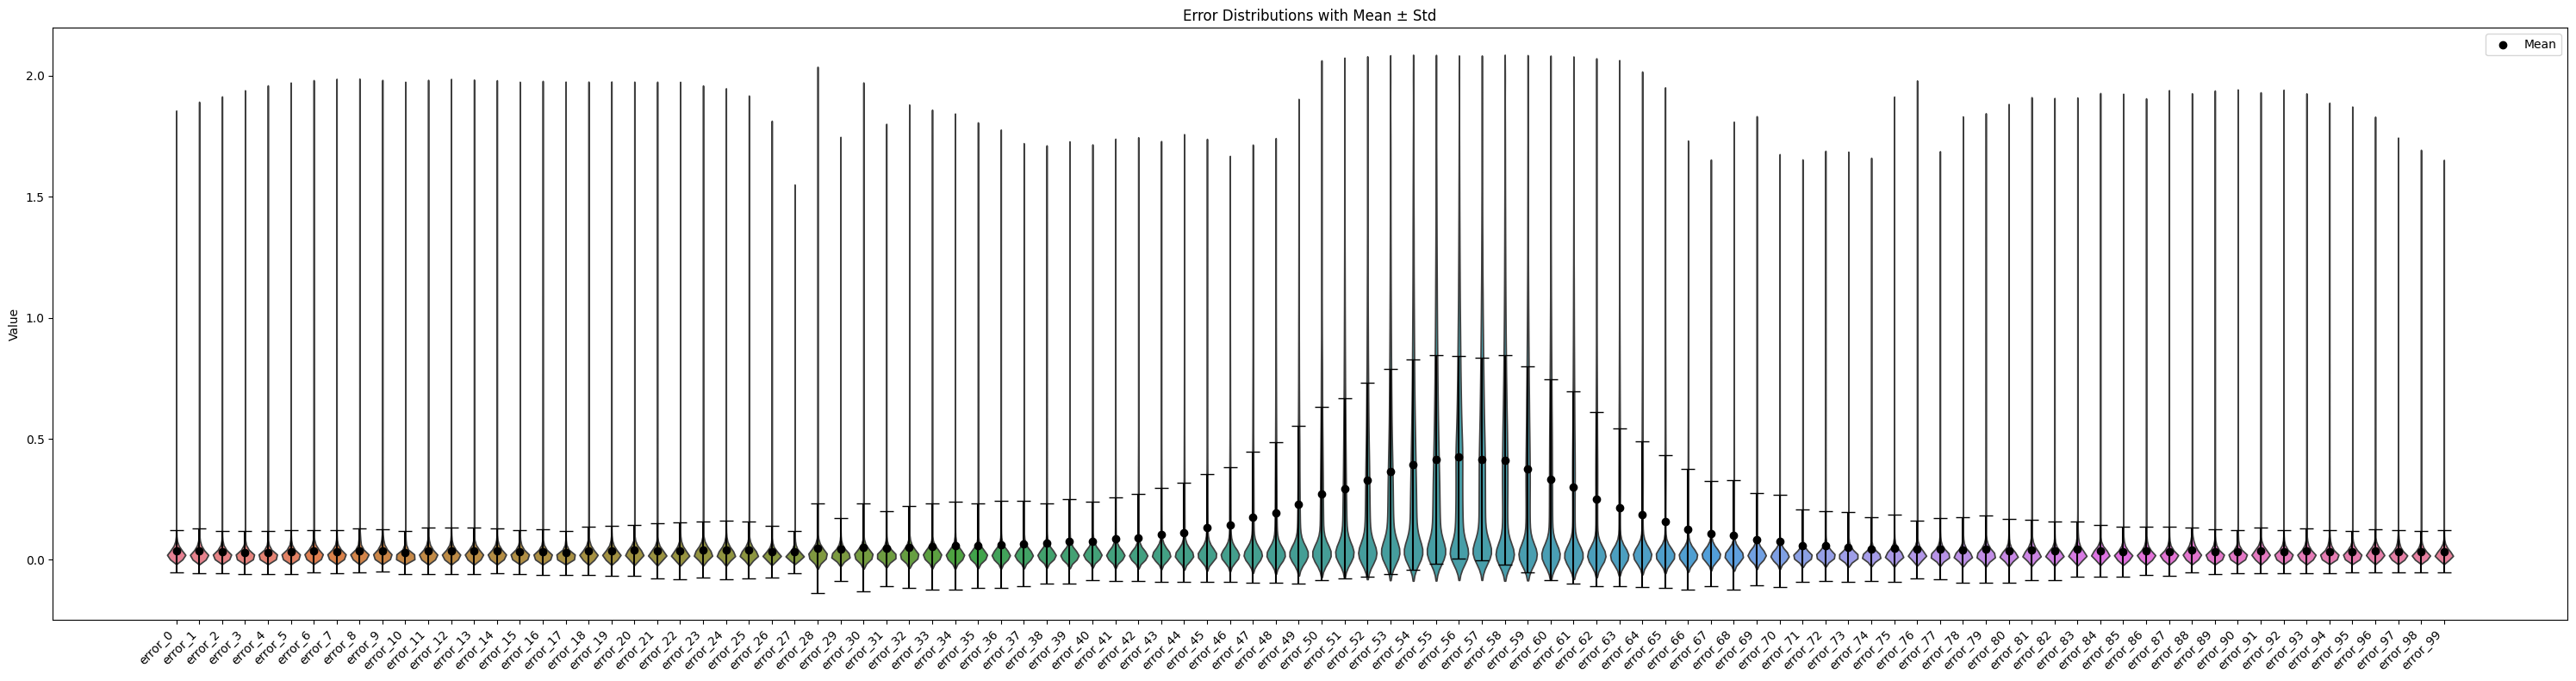

error_0     0.036629
error_1     0.036948
error_2     0.033187
error_3     0.031314
error_4     0.030561
              ...   
error_95    0.032845
error_96    0.036948
error_97    0.034171
error_98    0.032318
error_99    0.035176
Length: 100, dtype: float64 
 error_0     0.087264
error_1     0.092424
error_2     0.087226
error_3     0.089192
error_4     0.088908
              ...   
error_95    0.085951
error_96    0.089517
error_97    0.087530
error_98    0.084903
error_99    0.087298
Length: 100, dtype: float64 
               mean       std    median       skew    kurtosis  is_zero_test
error_0   0.036629  0.087264  0.022913   9.707256  111.573706         False
error_1   0.036948  0.092424  0.020770   9.102842   98.355137         False
error_2   0.033187  0.087226  0.019351   9.826911  113.508360         False
error_3   0.031314  0.089192  0.017191   9.789641  111.646321         False
error_4   0.030561  0.088908  0.017014  10.208353  120.999489         False
...            ...    

In [6]:
means, std, summary = analyze_error_distribution('./data/results/bins_pglobal_error_dist.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [7]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 1000        # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = val.get_paths()
pdfs= val.get_pdf(n_steps_ahead=10, n_bins=100, use_global=True)


In [8]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_pglobal')
conditional_gan.load_models()

CGAN config loaded from ./models\CGAN_bins_pglobal_config.json
Generator loaded from ./models\CGAN_bins_pglobal_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [128, 256, 128], 'is_prob': True, 'use_batch_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\CGAN_bins_pglobal_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [256, 128], 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}


In [9]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df


,p_values
0,1.750269e-19
1,9.258694e-19
2,3.418406e-58
3,2.593388e-63
4,1.589206e-64
...,...
995,1.877653e-03
996,8.481932e-10
997,1.101075e-82
998,3.587604e-47


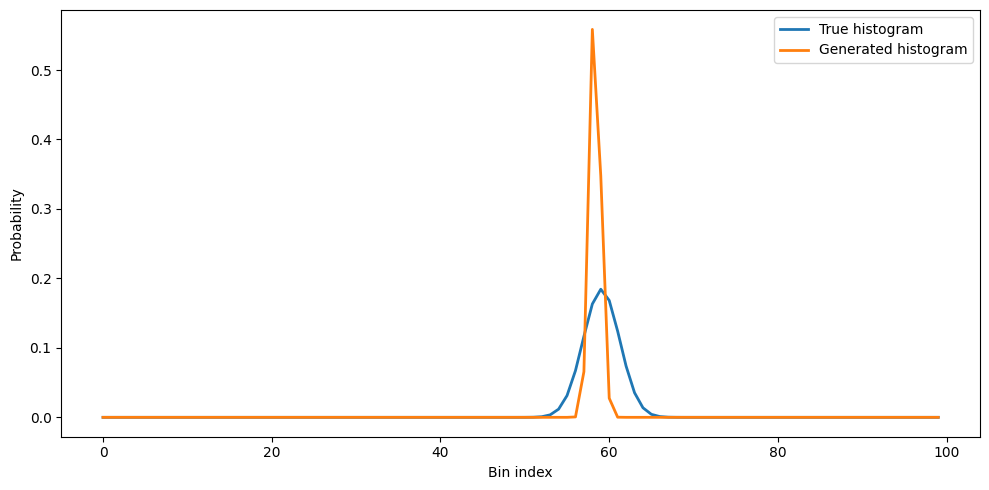

In [10]:
generated_sample = generated[-1]
true_sample = pdfs[-1]

plot_bin_dist(true_sample, generated_sample)



# BINS DISTRIBUTION EXPECTED VALUE

In [22]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100, use_cdf=False)
pdfs

array([[ 0.22619865,  0.23263816,  0.23907766, ...,  0.85082972,
         0.85726922,  0.86370873],
       [ 0.42191464,  0.42816471,  0.43441478, ...,  1.0281706 ,
         1.03442067,  1.04067074],
       [-0.40649944, -0.39267175, -0.37884406, ...,  0.9347839 ,
         0.94861158,  0.96243927],
       ...,
       [ 0.20895365,  0.216874  ,  0.22479435, ...,  0.97722635,
         0.9851467 ,  0.99306705],
       [ 0.06833169,  0.07003847,  0.07174526, ...,  0.23388978,
         0.23559657,  0.23730336],
       [ 0.0266579 ,  0.03464951,  0.04264112, ...,  0.80184294,
         0.80983455,  0.81782616]], shape=(100000, 100))

In [23]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='standardization')


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_ev')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_error_dist_ev.csv')


Epoch: 0/100, Step: 0, D Loss: 1.4008004665374756, G Loss: 0.6909524202346802
Epoch: 0/100, Step: 500, D Loss: 1.0090444087982178, G Loss: 0.9772014617919922
Epoch: 0/100, Step: 1000, D Loss: 1.4664034843444824, G Loss: 0.7236765623092651
Epoch: 0/100, Step: 1500, D Loss: 0.835260272026062, G Loss: 1.591605305671692
Epoch: 0/100, Step: 2000, D Loss: 1.1472585201263428, G Loss: 1.1714714765548706
Epoch: 0/100, Step: 2500, D Loss: 1.2396183013916016, G Loss: 2.188847303390503
Epoch: 0/100, Step: 3000, D Loss: 0.5499898195266724, G Loss: 3.9900362491607666
pred: [0.68059325 0.5104118  0.34483287 0.56008667 0.62739837], true: [0.98700362 0.98409182 0.98113412 0.97813016 0.97507936] 


Epoch: 1/100, Step: 3500, D Loss: 1.148324966430664, G Loss: 1.5029312372207642
Epoch: 1/100, Step: 4000, D Loss: 0.6336289644241333, G Loss: 6.404264450073242
Epoch: 1/100, Step: 4500, D Loss: 0.7800193428993225, G Loss: 3.148057460784912
Epoch: 1/100, Step: 5000, D Loss: 1.3666961193084717, G Loss: 0.969350

c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\my_cGAN.py:532: RuntimeWarning: divide by zero encountered in divide
  errors = (generated - true)/true
c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\.venv\Lib\site-packages\numpy\_core\_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Results saved to ./data/results/bins_error_dist_ev.csv


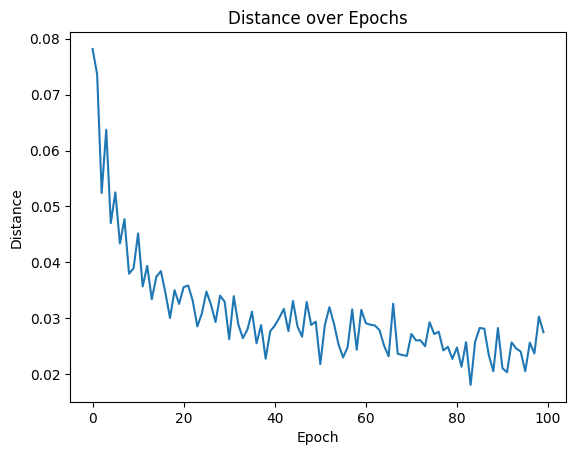

In [24]:
plot_learning_curve('generated_vs_true.csv')

c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\.venv\Lib\site-packages\scipy\stats\_stats_py.py:1158: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean
c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\.venv\Lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\.venv\Lib\site-packages\pandas\core\nanops.py:1344: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


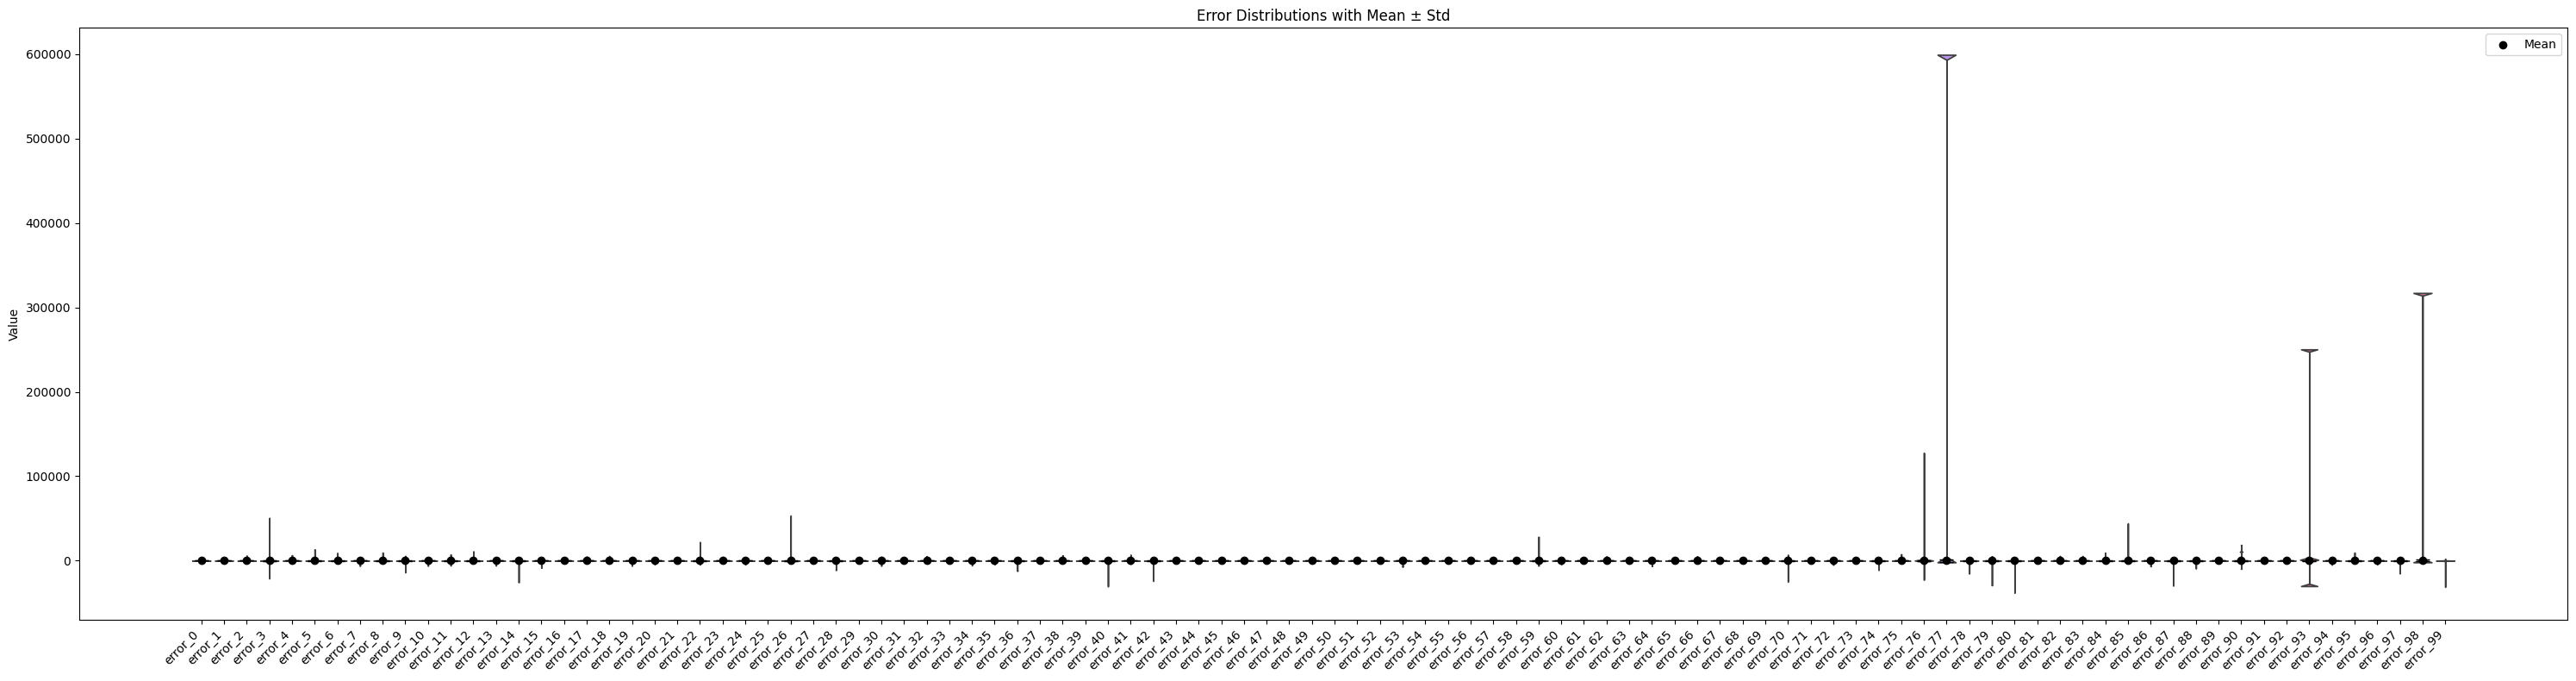

error_0    -0.104721
error_1     0.069064
error_2    -0.042354
error_3     0.357071
error_4     0.026696
              ...   
error_95   -0.051607
error_96   -0.066026
error_97   -0.098317
error_98    3.211584
error_99         inf
Length: 100, dtype: float64 
 error_0       21.530269
error_1       23.698683
error_2       25.103927
error_3      175.710840
error_4       25.377522
               ...     
error_95      35.152227
error_96      25.798046
error_97      51.682576
error_98    1002.140927
error_99            NaN
Length: 100, dtype: float64 
               mean          std    median        skew      kurtosis  \
error_0  -0.104721    21.530269 -0.111538  -21.993320  14333.474186   
error_1   0.069064    23.698683 -0.071868   76.363074  17521.087634   
error_2  -0.042354    25.103927 -0.104539  120.078293  39210.441678   
error_3   0.357071   175.710840 -0.092589  223.242438  71361.176953   
error_4   0.026696    25.377522 -0.079340  168.227903  43268.795762   
...            ... 

In [25]:
means, std, summary = analyze_error_distribution('./data/results/bins_error_dist_ev.csv')
print(means,'\n', std, '\n', summary)

# KS test 